In [15]:
import os
print(os.getcwd())

c:\Users\User.DESKTOP-775\ml_projects\fraud-detection-ml-platform\notebooks


In [16]:
# Import pandas library
import pandas as pd

# Load the fraud transaction dataset
df = pd.read_csv("../data/raw/transactions.csv")

# Display the first 5 rows of the dataset
df.head(5)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [17]:
# Check the number of rows and columns in the dataset
df.shape

(11400, 26)

In [18]:
# Display all column names in the dataset
df.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='str')

In [19]:
# Display dataset structure, column data types, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  str    
 1   customer_id                11400 non-null  str    
 2   timestamp                  11371 non-null  str    
 3   home_country               11400 non-null  str    
 4   source_currency            11400 non-null  str    
 5   dest_currency              11400 non-null  str    
 6   channel                    11400 non-null  str    
 7   amount_src                 11400 non-null  str    
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  str    
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  str    
 14  i

In [20]:
# Check for missing values in each column
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [21]:
# Check the distribution of fraudulent and legitimate transactions
df["is_fraud"].value_counts()

is_fraud
0    10403
1      997
Name: count, dtype: int64

In [22]:
# Generate statistical summary of numerical columns in the dataset
df.describe()

,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11095.000000,11105.000000,11400.000000,11400.000000,11400.000000,11105.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000
mean,452.022083,100.309441,167.540397,0.396726,393.793158,0.653681,0.048509,0.267134,0.458333,0.723509,0.045501,0.087456
std,1403.973062,958.128504,382.023827,0.270507,342.348393,0.273012,0.256194,0.142983,1.524494,1.958390,0.084942,0.282515
min,7.230000,-1.000000,0.592000,0.004000,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,92.465000,2.380000,1.000000,0.209000,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,163.480000,3.500000,7.142857,0.325000,298.000000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,302.190000,5.550000,73.529412,0.487000,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,12498.570000,9999.990000,1388.888889,1.200000,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


In [13]:
# Display all columns in the dataframe output
pd.set_option("display.max_columns", None)

In [23]:
# Display up to 100 rows
pd.set_option("display.max_rows", 100)

In [25]:
# Display first 10 rows
df.head(5)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [26]:
# Calculate the percentage of missing values in each column
(df.isnull().sum() / len(df)) * 100

transaction_id               0.000000
customer_id                  0.000000
timestamp                    0.254386
home_country                 0.000000
source_currency              0.000000
dest_currency                0.000000
channel                      0.000000
amount_src                   0.000000
amount_usd                   2.675439
fee                          2.587719
exchange_rate_src_to_dest    0.000000
device_id                    0.000000
new_device                   0.000000
ip_address                   2.675439
ip_country                   2.640351
location_mismatch            0.000000
ip_risk_score                0.000000
kyc_tier                     2.631579
account_age_days             0.000000
device_trust_score           2.587719
chargeback_history_count     0.000000
risk_score_internal          0.000000
txn_velocity_1h              0.000000
txn_velocity_24h             0.000000
corridor_risk                0.000000
is_fraud                     0.000000
dtype: float

In [27]:
# Check duplicate records
df.duplicated().sum()

np.int64(200)

In [28]:
# Drop identifier columns that do not add predictive value
identifier_cols = [
    "transaction_id",
    "customer_id",
    "device_id",
    "ip_address"
]

df = df.drop(columns=identifier_cols)

In [29]:
# Remove duplicate records
df = df.drop_duplicates()

In [30]:

# Confirm duplicate records have been removed
df.duplicated().sum()

np.int64(0)

In [31]:
# Convert timestamp column to datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

In [32]:

# Convert amount_src column to numeric format
df["amount_src"] = pd.to_numeric(df["amount_src"], errors="coerce")

In [34]:
# Fill missing numerical values using median
numeric_cols = [
    "amount_src",
    "amount_usd",
    "fee",
    "device_trust_score"
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [35]:
# Fill missing categorical values with 'unknown'
categorical_cols = [
    "ip_country",
    "kyc_tier"
]

for col in categorical_cols:
    df[col] = df[col].fillna("unknown")

In [36]:
# Remove rows with missing or invalid timestamps
df = df.dropna(subset=["timestamp"])

In [37]:
# Fix inconsistencies in categorical variables by converting text to lowercase and removing extra spaces
categorical_columns = [
    "home_country",
    "source_currency",
    "dest_currency",
    "channel",
    "ip_country",
    "kyc_tier"
]

for col in categorical_columns:
    df[col] = df[col].astype(str).str.lower().str.strip()

In [38]:
# Convert boolean columns to integer format for modelling
df["new_device"] = df["new_device"].astype(int)
df["location_mismatch"] = df["location_mismatch"].astype(int)

In [39]:
# Remove invalid negative values from operational fields
df = df[df["fee"] >= 0]
df = df[df["txn_velocity_1h"] >= 0]
df = df[df["device_trust_score"] >= 0]

In [40]:
# Create time-based features for fraud pattern analysis
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.day_name()
df["month"] = df["timestamp"].dt.month

In [41]:
# Check cleaned dataset structure
df.info()

<class 'pandas.DataFrame'>
Index: 10940 entries, 0 to 11399
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   timestamp                  10940 non-null  datetime64[us, UTC]
 1   home_country               10940 non-null  str                
 2   source_currency            10940 non-null  str                
 3   dest_currency              10940 non-null  str                
 4   channel                    10940 non-null  str                
 5   amount_src                 10940 non-null  float64            
 6   amount_usd                 10940 non-null  float64            
 7   fee                        10940 non-null  float64            
 8   exchange_rate_src_to_dest  10940 non-null  float64            
 9   new_device                 10940 non-null  int64              
 10  ip_country                 10940 non-null  str                
 11  location_mismatch 

In [43]:
# Show all columns
pd.set_option('display.max_columns', None)

In [44]:
# Display dataframe content across the full notebook width
pd.set_option('display.width', None)

# Display full content of each column without truncation
pd.set_option('display.max_colwidth', None)

In [45]:
# Display dataset information
print(df.info())

<class 'pandas.DataFrame'>
Index: 10940 entries, 0 to 11399
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   timestamp                  10940 non-null  datetime64[us, UTC]
 1   home_country               10940 non-null  str                
 2   source_currency            10940 non-null  str                
 3   dest_currency              10940 non-null  str                
 4   channel                    10940 non-null  str                
 5   amount_src                 10940 non-null  float64            
 6   amount_usd                 10940 non-null  float64            
 7   fee                        10940 non-null  float64            
 8   exchange_rate_src_to_dest  10940 non-null  float64            
 9   new_device                 10940 non-null  int64              
 10  ip_country                 10940 non-null  str                
 11  location_mismatch 

In [46]:
df.columns

Index(['timestamp', 'home_country', 'source_currency', 'dest_currency',
       'channel', 'amount_src', 'amount_usd', 'fee',
       'exchange_rate_src_to_dest', 'new_device', 'ip_country',
       'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days',
       'device_trust_score', 'chargeback_history_count', 'risk_score_internal',
       'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud',
       'hour', 'day_of_week', 'month'],
      dtype='str')

In [47]:
# Confirm remaining missing values after cleaning
df.isnull().sum()

timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
new_device                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
hour                         0
day_of_week                  0
month                        0
dtype: int64

In [48]:
# Check cleaned dataset shape
df.shape

(10940, 25)

In [49]:
df.head(5)

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,hour,day_of_week,month
0,2022-10-03 18:40:59.468549+00:00,us,usd,cad,atm,278.19,278.19,4.25,1.351351,0,us,0,0.123,standard,263,0.522,0,0.223,0,0,0.0,0,18,Monday,10
1,2022-10-03 20:39:38.468549+00:00,ca,cad,mxn,web,208.51,154.29,4.24,12.758621,1,ca,0,0.569,standard,947,0.475,0,0.268,0,1,0.0,0,20,Monday,10
2,2022-10-03 23:02:43.468549+00:00,us,usd,cny,mobile,160.33,160.33,2.70,7.142857,0,us,0,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0,23,Monday,10
3,2022-10-04 01:08:53.468549+00:00,us,usd,eur,mobile,59.41,59.41,2.22,0.925926,0,us,0,0.594,standard,147,0.551,0,0.391,0,0,0.0,0,1,Tuesday,10
4,2022-10-04 09:35:03.468549+00:00,us,usd,inr,mobile,200.96,200.96,3.61,83.333333,0,us,0,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0,9,Tuesday,10


In [50]:
# Convert binary columns to boolean
binary_cols = ["new_device", "location_mismatch", "is_fraud"]

for col in binary_cols:
    df[col] = df[col].astype("bool")

In [51]:

# Convert text/categorical columns to category
cat_cols = [
    "home_country",
    "source_currency",
    "dest_currency",
    "channel",
    "ip_country",
    "kyc_tier",
    "day_of_week",
    "month"
]

for col in cat_cols:
    df[col] = df[col].astype("category")

In [52]:
# Check data types
df.info()

<class 'pandas.DataFrame'>
Index: 10940 entries, 0 to 11399
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   timestamp                  10940 non-null  datetime64[us, UTC]
 1   home_country               10940 non-null  category           
 2   source_currency            10940 non-null  category           
 3   dest_currency              10940 non-null  category           
 4   channel                    10940 non-null  category           
 5   amount_src                 10940 non-null  float64            
 6   amount_usd                 10940 non-null  float64            
 7   fee                        10940 non-null  float64            
 8   exchange_rate_src_to_dest  10940 non-null  float64            
 9   new_device                 10940 non-null  bool               
 10  ip_country                 10940 non-null  category           
 11  location_mismatch 

In [53]:
df.head(5)

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,hour,day_of_week,month
0,2022-10-03 18:40:59.468549+00:00,us,usd,cad,atm,278.19,278.19,4.25,1.351351,False,us,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,False,18,Monday,10
1,2022-10-03 20:39:38.468549+00:00,ca,cad,mxn,web,208.51,154.29,4.24,12.758621,True,ca,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,False,20,Monday,10
2,2022-10-03 23:02:43.468549+00:00,us,usd,cny,mobile,160.33,160.33,2.70,7.142857,False,us,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,False,23,Monday,10
3,2022-10-04 01:08:53.468549+00:00,us,usd,eur,mobile,59.41,59.41,2.22,0.925926,False,us,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,False,1,Tuesday,10
4,2022-10-04 09:35:03.468549+00:00,us,usd,inr,mobile,200.96,200.96,3.61,83.333333,False,us,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,False,9,Tuesday,10


In [54]:
# Convert boolean columns to integer format
binary_cols = [
    "new_device",
    "location_mismatch",
    "is_fraud"
]

for col in binary_cols:
    df[col] = df[col].astype(int)

In [55]:
# Check updated data types
df.info()

<class 'pandas.DataFrame'>
Index: 10940 entries, 0 to 11399
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   timestamp                  10940 non-null  datetime64[us, UTC]
 1   home_country               10940 non-null  category           
 2   source_currency            10940 non-null  category           
 3   dest_currency              10940 non-null  category           
 4   channel                    10940 non-null  category           
 5   amount_src                 10940 non-null  float64            
 6   amount_usd                 10940 non-null  float64            
 7   fee                        10940 non-null  float64            
 8   exchange_rate_src_to_dest  10940 non-null  float64            
 9   new_device                 10940 non-null  int64              
 10  ip_country                 10940 non-null  category           
 11  location_mismatch 

In [56]:
df.tail(5)

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,hour,day_of_week,month
11395,2025-11-25 10:05:35.573611+00:00,us,usd,cad,mobile,271.25,271.25,5.24,1.351351,0,us,0,0.307,standard,742,0.653,0,0.302,1,2,0.00,0,10,Tuesday,11
11396,2025-11-26 07:09:56.573611+00:00,ca,cad,ngn,web,537.17,397.51,8.86,822.222222,0,uk,1,0.891,low,9,0.173,2,0.730,3,6,0.00,1,7,Wednesday,11
11397,2025-11-27 06:19:11.573611+00:00,ca,cad,inr,web,205.15,151.81,4.00,61.666667,1,us,1,1.000,low,21,0.269,1,0.605,3,4,0.12,1,6,Thursday,11
11398,2025-11-28 00:53:28.573611+00:00,us,usd,php,mobile,78.03,78.03,1.96,58.823529,0,us,0,0.298,enhanced,471,0.773,0,0.375,0,2,0.00,0,0,Friday,11
11399,2025-11-29 20:10:47.573611+00:00,us,usd,ngn,web,1214.16,1214.16,19.34,1111.111111,1,us,0,1.000,low,58,0.187,0,0.646,4,6,0.25,1,20,Saturday,11


In [57]:
# Analyse fraud rate by transaction channel
df.groupby("channel")["is_fraud"].mean().sort_values(ascending=False)

channel
web        0.166849
atm        0.082822
mobile     0.047873
unknown    0.027027
mobille    0.000000
weeb       0.000000
Name: is_fraud, dtype: float64

In [58]:
# Fix inconsistent channel category values
df["channel"] = df["channel"].replace({
    "mobille": "mobile",
    "weeb": "web"
})

In [59]:
# Check cleaned channel categories
df["channel"].unique()

['atm', 'web', 'mobile', 'unknown']
Categories (6, str): ['atm', 'mobile', 'mobille', 'unknown', 'web', 'weeb']

In [60]:
# Remove unused categories from the channel column
df["channel"] = df["channel"].cat.remove_unused_categories()

In [61]:
# Check unique channel categories after cleanup
df["channel"].unique()

['atm', 'web', 'mobile', 'unknown']
Categories (4, str): ['atm', 'mobile', 'unknown', 'web']

In [62]:
# Analyse fraud rate by transaction channel
df.groupby("channel")["is_fraud"].mean().sort_values(ascending=False)

channel
web        0.165807
atm        0.082822
mobile     0.047436
unknown    0.027027
Name: is_fraud, dtype: float64

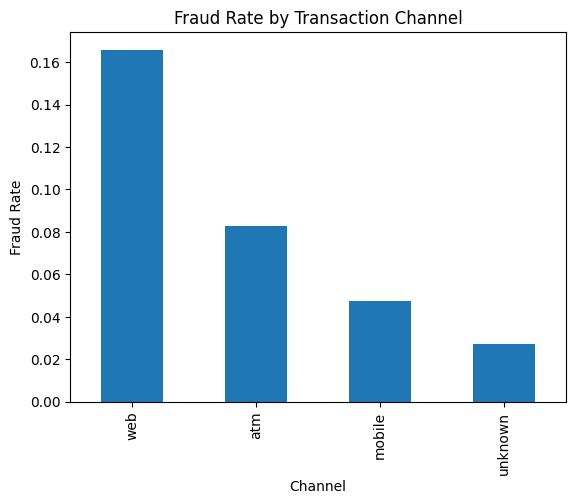

In [64]:
# Visualise fraud rate by transaction channel
import matplotlib.pyplot as plt

channel_fraud = df.groupby("channel")["is_fraud"].mean().sort_values(ascending=False)

channel_fraud.plot(kind="bar")

plt.title("Fraud Rate by Transaction Channel")
plt.xlabel("Channel")
plt.ylabel("Fraud Rate")

plt.show()

In [65]:
# Compare transaction velocity between fraudulent and legitimate transactions
df.groupby("is_fraud")[["txn_velocity_1h", "txn_velocity_24h"]].mean()

,txn_velocity_1h,txn_velocity_24h
is_fraud,,
0,0.155361,0.271229
1,3.872599,5.510617


In [66]:
# Compare device trust score between fraudulent and legitimate transactions
df.groupby("is_fraud")["device_trust_score"].mean()

is_fraud
0    0.701910
1    0.314668
Name: device_trust_score, dtype: float64

In [67]:
# Compare IP risk score between fraudulent and legitimate transactions
df.groupby("is_fraud")["ip_risk_score"].mean()

is_fraud
0    0.336642
1    0.850908
Name: ip_risk_score, dtype: float64

In [68]:
# Analyse fraud distribution across KYC tiers
pd.crosstab(df["kyc_tier"], df["is_fraud"], normalize="index")

is_fraud,0,1
kyc_tier,,
enhancd,1.000000,0.000000
enhanced,0.977095,0.022905
low,0.482592,0.517408
nan,1.000000,0.000000
standard,0.947641,0.052359
standrd,0.985714,0.014286
unknown,0.974603,0.025397


In [69]:
# Fix spelling inconsistencies in kyc_tier

df["kyc_tier"] = df["kyc_tier"].replace({
    "enhancd": "enhanced",
    "standrd": "standard"
})

# Verify unique values
print(df["kyc_tier"].unique())

['standard', 'enhanced', 'low', 'unknown', 'nan']
Categories (7, str): ['enhancd', 'enhanced', 'low', 'nan', 'standard', 'standrd', 'unknown']


In [70]:
# Remove unused categories after replacement
df["kyc_tier"] = df["kyc_tier"].cat.remove_unused_categories()

# Check categories again
print(df["kyc_tier"].unique())

['standard', 'enhanced', 'low', 'unknown', 'nan']
Categories (5, str): ['enhanced', 'low', 'nan', 'standard', 'unknown']


In [71]:
kyc_fraud = pd.crosstab(
    df["kyc_tier"],
    df["is_fraud"],
    normalize="index"
)

print((kyc_fraud * 100).round(2))

is_fraud       0      1
kyc_tier               
enhanced   97.72   2.28
low        48.26  51.74
nan       100.00   0.00
standard   94.80   5.20
unknown    97.46   2.54


In [72]:
import numpy as np

# Convert string 'nan' to actual missing value
df["kyc_tier"] = df["kyc_tier"].replace("nan", np.nan)

# Remove unused categories
df["kyc_tier"] = df["kyc_tier"].cat.remove_unused_categories()

In [73]:
print(df["kyc_tier"].unique())

['standard', 'enhanced', 'low', 'unknown', NaN]
Categories (4, str): ['enhanced', 'low', 'standard', 'unknown']


In [74]:
df["kyc_tier"].isna().sum()

np.int64(3)

In [76]:
# Fill missing values in kyc_tier with "unknown"
# ============================================================
# Reason:
# Missing KYC information may itself indicate higher risk.
# Instead of dropping the rows, we preserve the transactions
# and label the missing category as "unknown".

df["kyc_tier"] = df["kyc_tier"].fillna("unknown")

In [77]:
# Verify that no missing values remain
print(df["kyc_tier"].isna().sum())

0


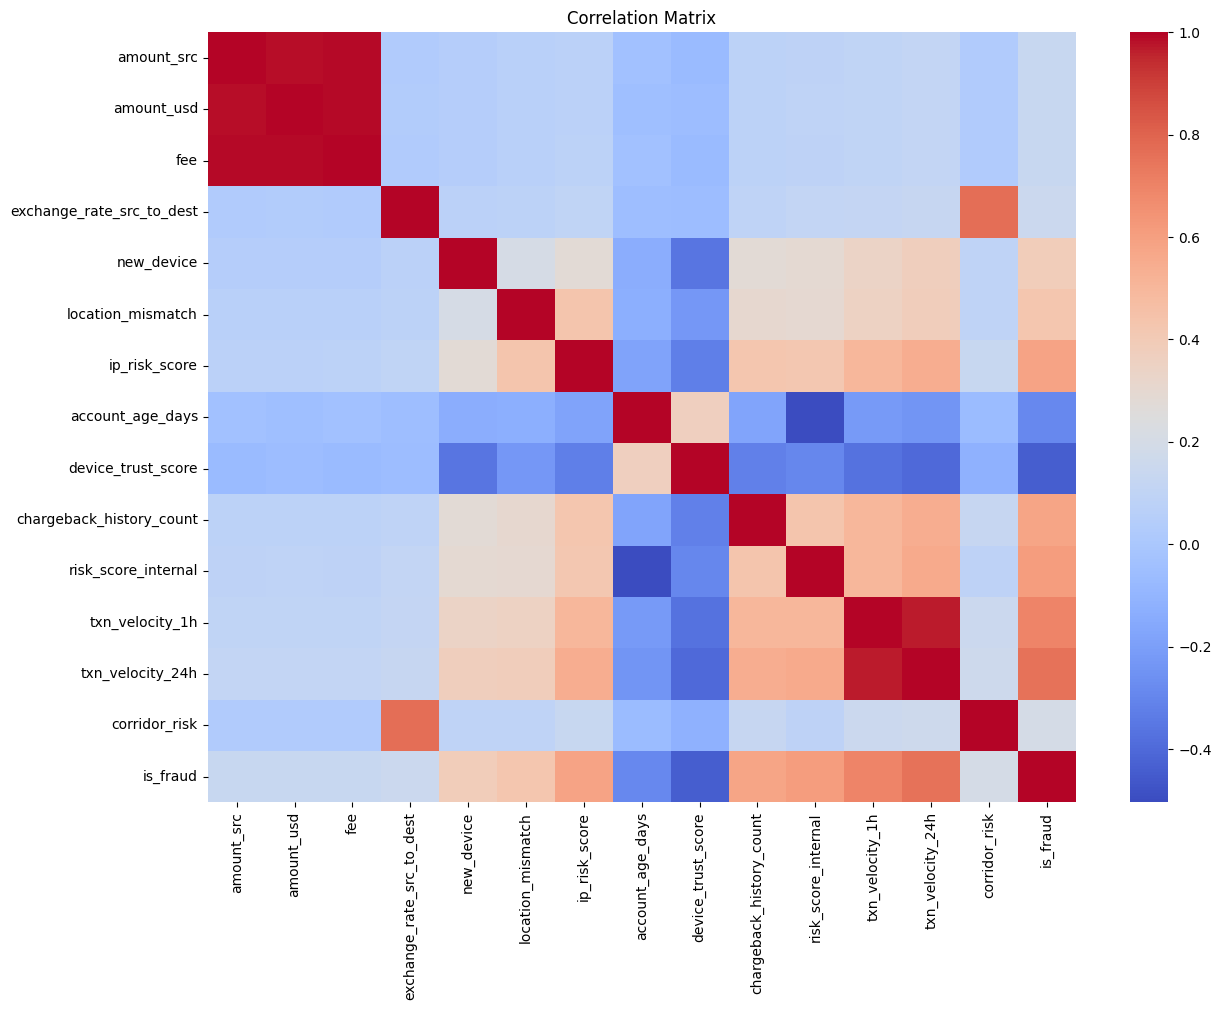

In [79]:
# Generate correlation matrix for numerical features

import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns only
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

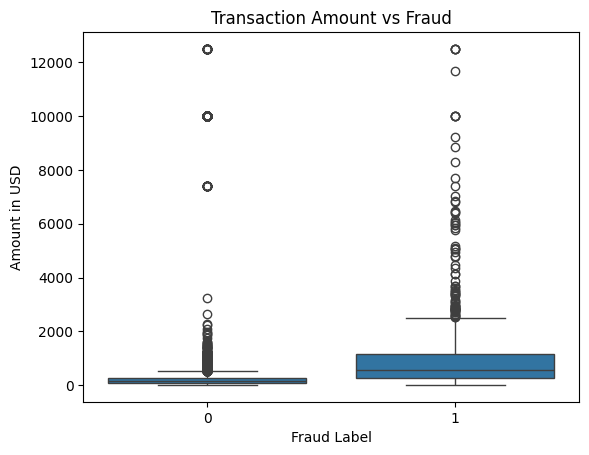

In [80]:
# Analyse transaction amount outliers by fraud label
sns.boxplot(x="is_fraud", y="amount_usd", data=df)
plt.title("Transaction Amount vs Fraud")
plt.xlabel("Fraud Label")
plt.ylabel("Amount in USD")
plt.show()

In [ ]:
# Save cleaned dataset 
df.to_csv("../data/processed/cleaned_transactions.csv", index=False)